# Machine Learning Phase

In this section, I apply machine learning methods to analyze AI-related job market data. The main goal is to predict job experience level and salary using features such as demand score, education requirement, required skills, and AI salary premium.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

Now I load the cleaned dataset created in the previous phase of the project.

In [5]:
df = pd.read_csv("ai_jobs_market_cleaned.xls")
df.head()

,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,entry_vs_senior,salary_midpoint_check
0,AI Engineering,Senior,7,Master,239000.0,155000,290000,Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,1,Senior,222500.0
1,AI Engineering,Senior,2,Bachelor,166000.0,90000,200000,Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,1,Senior,145000.0
2,AI Engineering,Senior,4,Associate,360000.0,160000,300000,Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,1,Senior,230000.0
3,Data Engineering,Senior,3,Bachelor,161000.0,130000,220000,Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,0,Senior,175000.0
4,Product,Lead,5,Bootcamp/Self-taught,283000.0,140000,260000,Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,0,Other,200000.0


## Selecting Features for Machine Learning

To keep the model focused and interpretable, I select variables related to salary, demand, education, skills, and experience level.

In [6]:
selected_columns = [
    "demand_score",
    "annual_salary_usd",
    "ai_salary_premium_pct",
    "education_required",
    "required_skills",
    "experience_level"
]

df_ml = df[selected_columns].copy()
df_ml.head()

,demand_score,annual_salary_usd,ai_salary_premium_pct,education_required,required_skills,experience_level
0,96,239000.0,13.1,Master,APIs|Planning Systems|Python|Cloud|SQL|Leadership,Senior
1,82,166000.0,5.4,Bachelor,Python|Documentation|LLM APIs|Prompt Design|NL...,Senior
2,98,360000.0,9.1,Associate,Vector DBs|Python|Prompt Engineering|Fine-tuni...,Senior
3,88,161000.0,12.0,Bachelor,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,Senior
4,85,283000.0,9.4,Bootcamp/Self-taught,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,Lead


## Defining the First ML Task

The first task is a classification problem.  
I will try to predict the **experience level** of a job posting using the other features.

In [7]:
X = df_ml.drop("experience_level", axis=1)
y = df_ml["experience_level"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClasses:")
print(y.value_counts())

Features shape: (1500, 5)
Target shape: (1500,)

Classes:
experience_level
Entry     385
Lead      381
Mid       370
Senior    364
Name: count, dtype: int64


## Splitting the Data

I divide the dataset into two parts:

- **80% Training Set:** used to train the model and learn patterns from the data  
- **20% Test Set:** used to evaluate model performance on unseen data


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1200, 5)
Test set: (300, 5)


## Training the First Classification Model

I start with **Logistic Regression** as a baseline classification model.  


In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categoric", categorical_transformer, categorical_features)
    ]
)
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

Numeric features: ['demand_score', 'annual_salary_usd', 'ai_salary_premium_pct']
Categorical features: ['education_required', 'required_skills']


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['demand_score',
                                                   'annual_salary_usd',
                                                   'ai_salary_premium_pct']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_required',
                                                   'required_skills'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

The figure below presents the machine learning pipeline. Numerical features were cleaned and scaled, categorical features were encoded, and the processed data was then used to train the Logistic Regression model.

## Making Predictions

After training the model, I use the test dataset to predict experience levels for unseen job postings.

In [15]:
y_pred = log_model.predict(X_test)

## Evaluating Model Performance

To evaluate the model, I use accuracy score and classification metrics such as precision, recall, and F1-score.

In [16]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.43

Classification Report:

              precision    recall  f1-score   support

       Entry       0.47      0.78      0.58        77
        Lead       0.53      0.61      0.57        76
         Mid       0.25      0.16      0.20        74
      Senior       0.30      0.15      0.20        73

    accuracy                           0.43       300
   macro avg       0.39      0.42      0.39       300
weighted avg       0.39      0.43      0.39       300



## Confusion Matrix

To better understand the model's predictions, I use a confusion matrix. It shows how many job postings were correctly classified and where the model confused different experience levels.

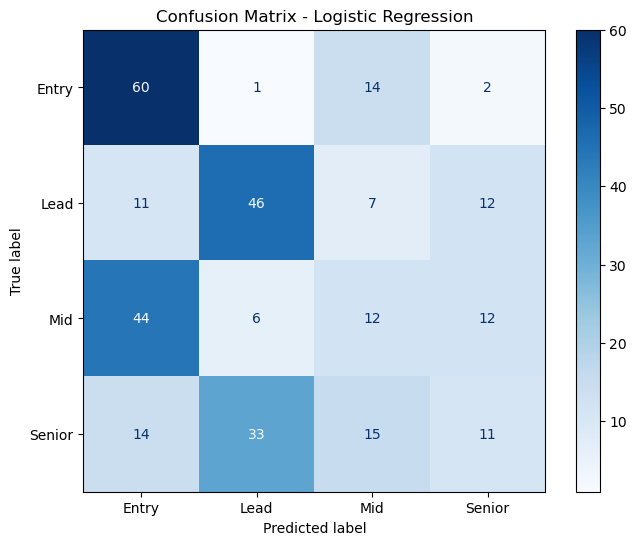

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Entry", "Lead", "Mid", "Senior"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model predicts Entry and Lead positions more accurately, while Mid and Senior roles are more frequently misclassified.

## Improving the Model with Gradient Boosting

After using Logistic Regression as a baseline model, I apply Gradient Boosting Classifier as a stronger method. This model builds multiple weak learners step by step and often performs better on structured datasets.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['demand_score',
                                                   'annual_salary_usd',
                                                   'ai_salary_premium_pct']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_required',
                                                   'required_skills'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

## Visualizing Gradient Boosting Predictions

I use a confusion matrix again to see how the Gradient Boosting model predicts each experience level.

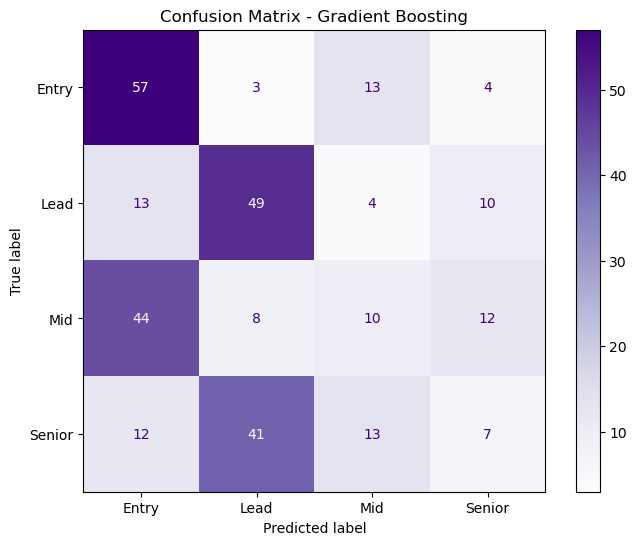

In [22]:
y_pred_gb = gb_model.predict(X_test)

cm_gb = confusion_matrix(y_test, y_pred_gb, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Purples", ax=ax, values_format="d")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

Gradient Boosting did not improve the results significantly because the selected features may not contain enough information to clearly separate experience levels. In many cases, Entry, Mid, and Senior roles can have similar salaries, skills, or education requirements, which makes classification difficult even for more advanced models.

## Comparing Model Accuracy

To compare the classification models, I summarize their accuracy scores below.

In [23]:
log_acc = accuracy_score(y_test, y_pred)
gb_acc = accuracy_score(y_test, y_pred_gb)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosting"],
    "Accuracy": [log_acc, gb_acc]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.43
1,Gradient Boosting,0.41


The table above shows that both models achieved similar accuracy scores, indicating that model complexity alone did not significantly improve performance.

## Salary Prediction with Regression

After the classification task, I now focus on predicting annual salary. This is a regression problem because salary is a continuous numerical variable.

In [24]:
X_reg = df_ml.drop("annual_salary_usd", axis=1)
y_reg = df_ml["annual_salary_usd"]

## Splitting the Regression Dataset

I divide the data into training and test sets using 80% for training and 20% for testing.

In [25]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

## Preparing Features for Regression

I separate numerical and categorical variables again so they can be preprocessed correctly.

In [26]:
numeric_features_reg = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_reg = X_reg.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features_reg)
print("Categorical Features:", categorical_features_reg)

Numeric Features: ['demand_score', 'ai_salary_premium_pct']
Categorical Features: ['education_required', 'required_skills', 'experience_level']


## Building the Regression Preprocessing Pipeline

Numerical variables are scaled, while categorical variables are encoded before model training.

In [27]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reg),
        ("cat", categorical_transformer, categorical_features_reg)
    ]
)

## Training the Linear Regression Model

I first use Linear Regression as a baseline model for salary prediction.

In [28]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['demand_score',
                                                   'ai_salary_premium_pct']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_required',
                                                   'required_skills',
                                                   'experience_level'])])),
                ('regressor', LinearRegression())])

## Making Salary Predictions

Now I predict salaries for the test dataset.

In [29]:
y_pred_lr = lr_model.predict(X_test_reg)

## Evaluating Linear Regression Performance

To evaluate the model, I use:

- **MAE (Mean Absolute Error):** average prediction error  
- **RMSE (Root Mean Squared Error):** penalizes larger errors  
- **R² Score:** shows how much of the salary variation is explained by the model

In [30]:
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE: 42099.74124288946
RMSE: 53051.60795733875
R² Score: 0.3133722848233007


## Visualizing Predictions

The chart below compares actual salaries with predicted salaries. If predictions are strong, points should follow an upward diagonal pattern.

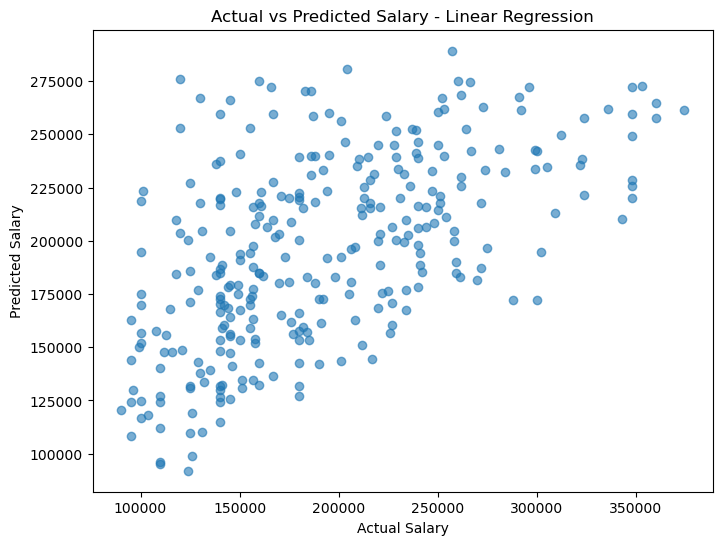

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary - Linear Regression")
plt.show()

The scatter plot shows a positive relationship between actual and predicted salaries, meaning the model captures general salary trends. However, the spread of points indicates that some prediction errors still remain.

## Improving Salary Prediction with Gradient Boosting Regressor

After using Linear Regression as a baseline model, I now apply Gradient Boosting Regressor. This model can capture more complex and non-linear relationships in salary data.

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("regressor", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gbr_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['demand_score',
                                                   'ai_salary_premium_pct']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education_required',
                                                   'required_skills',
                                                   'experience_level'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

## Predicting Salaries with Gradient Boosting

Now I generate salary predictions for the test dataset.

In [33]:
y_pred_gbr = gbr_model.predict(X_test_reg)

## Evaluating Gradient Boosting Regressor

I evaluate the improved model using the same regression metrics.

In [34]:
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr))
r2_gbr = r2_score(y_test_reg, y_pred_gbr)

print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R² Score:", r2_gbr)

MAE: 40456.29898364573
RMSE: 51701.38807895127
R² Score: 0.34787832922108486


## Visual Comparison of Predictions

The chart below compares actual salaries with predicted salaries from the Gradient Boosting model.

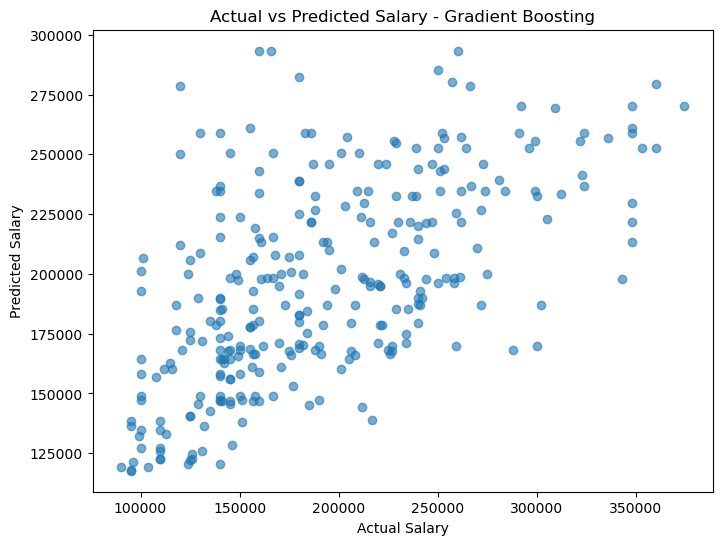

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_gbr, alpha=0.6)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary - Gradient Boosting")
plt.show()

Even the visuals look almost similar with gradient boosting we have lower MAE and RMSE, and higher R² Score. These illustrates that the model has improved using gradient boosting.

## Comparing Regression Models

To summarize the regression results, I compare Linear Regression and Gradient Boosting using the main evaluation metrics.

In [36]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "MAE": [mae_lr, mae_gbr],
    "RMSE": [rmse_lr, rmse_gbr],
    "R2 Score": [r2_lr, r2_gbr]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,42099.741243,53051.607957,0.313372
1,Gradient Boosting,40456.298984,51701.388079,0.347878


The table above shows that Gradient Boosting achieved better overall performance, making it the stronger model for salary prediction in this dataset.

## Final Conclusion

In the classification task, predicting experience level was challenging because job levels may share similar salaries, skills, and education requirements. More advanced models did not significantly improve the results.

In the regression task, salary prediction produced stronger outcomes. Gradient Boosting outperformed Linear Regression, suggesting that salary can be better explained using the available job market variables.

Overall, the machine learning phase shows that salary is easier to model than experience level in this dataset.